# 4.2 (KAN-10): Build price, arrivals, weather and calendar features

Parent: **Task 3 (KAN-6)**. Implements the feature list in [`docs/feature_list_and_rationale.md`](../docs/feature_list_and_rationale.md) (4.1, KAN-9).

**Input:** `data/panel_with_weather.csv` (Task 3)
**Output:** `data/features_panel.csv`, one row per mandi × crop × week with 38 numeric features, 2 categorical features, the targets and a chronological `split` column.

Steps
1. Build features with `scripts/build_features.py`
2. Drop warm-up weeks and define a chronological train/test split
3. **Leakage checks:** a truncation test and a feature-target screen
4. **Multicollinearity checks:** correlation matrix and VIF
5. Save the feature table

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.outliers_influence import variance_inflation_factor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
from build_features import (ARRIVAL_FEATURES, CALENDAR_FEATURES, CATEGORICAL_FEATURES, KEYS,
                            NUMERIC_FEATURES, PRICE_FEATURES, TARGETS, WEATHER_FEATURES,
                            build_features)

DATA = ROOT / "data"
FIG = ROOT / "reports" / "figures" / "task4"
FIG.mkdir(parents=True, exist_ok=True)

INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
GROUP_COLORS = {"Price": "#2a78d6", "Arrivals": "#eb6834", "Weather": "#1baf7a", "Calendar": "#eda100"}
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ec8a89", "#b52e2e"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e1",
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})
GROUP = {**{f: "Price" for f in PRICE_FEATURES}, **{f: "Arrivals" for f in ARRIVAL_FEATURES},
         **{f: "Weather" for f in WEATHER_FEATURES}, **{f: "Calendar" for f in CALENDAR_FEATURES}}
print(len(NUMERIC_FEATURES), "numeric features:", {g: list(GROUP.values()).count(g) for g in GROUP_COLORS})

38 numeric features: {'Price': 15, 'Arrivals': 5, 'Weather': 12, 'Calendar': 6}


## 1. Build features

In [2]:
panel = pd.read_csv(DATA / "panel_with_weather.csv", parse_dates=["week_start_date"])
full_weeks = panel[~panel["is_partial_week"]].copy()   # partial final week excluded (see Task 3)
feats_all = build_features(full_weeks)
print("built:", feats_all.shape)
feats_all[NUMERIC_FEATURES].describe().T.round(2)

built: (10920, 46)


,count,mean,std,min,25%,50%,75%,max
price,10920.0,1975.07,365.37,1189.33,1632.13,1992.17,2277.21,2878.50
price_lag_1,10710.0,1972.86,364.81,1189.33,1631.17,1989.58,2275.17,2878.50
price_lag_2,10500.0,1970.51,364.16,1189.33,1629.79,1987.42,2271.83,2878.50
price_lag_4,10080.0,1966.86,363.46,1189.33,1625.63,1983.00,2268.87,2878.50
pct_change_1w,10710.0,0.42,6.24,-25.09,-3.54,0.49,4.45,26.44
pct_change_2w,10500.0,0.69,6.97,-27.37,-3.50,1.14,5.34,24.53
pct_change_4w,10080.0,1.13,8.12,-24.83,-4.20,1.87,6.91,25.36
roll_mean_4,10290.0,1974.79,354.93,1299.21,1624.78,1995.94,2288.92,2716.29
roll_mean_8,9450.0,1974.44,350.48,1330.19,1622.19,1996.40,2297.25,2624.23
roll_std_4,10080.0,6.26,2.83,0.26,4.22,5.92,7.98,19.09


## 2. Warm-up rows and chronological split

Rows without a full 8-week history (the first 8 weeks of every series) or without a next-week target (the last full week) are dropped.

**Split:** train on weeks up to 2026-06-29 (about 75% of weeks), test on the last full quarter (2026-07-06 to 2026-09-14). A random split would leak future price levels into training.

In [3]:
TEST_START = pd.Timestamp("2026-07-06")
feats = feats_all.dropna(subset=NUMERIC_FEATURES + ["target_pct_change"]).reset_index(drop=True)
feats["split"] = np.where(feats["week_start_date"] >= TEST_START, "test", "train")

print("rows:", len(feats), "| dropped warm-up/last week:", len(feats_all) - len(feats))
print(feats.groupby("split")["week_start_date"].agg(["min", "max", "nunique", "size"]))
print("\nTarget class share by split:")
print(pd.crosstab(feats["split"], feats["target_direction"], normalize="index").round(3))

rows: 9030 | dropped warm-up/last week: 1890
             min        max  nunique  size
split                                     
test  2026-07-06 2026-09-14       11  2310
train 2025-11-24 2026-06-29       32  6720

Target class share by split:
target_direction   fall   flat   rise
split                                
test              0.251  0.352  0.397
train             0.326  0.323  0.350


## 3. Leakage checks

### 3a. Truncation test
If a feature for week `t` uses only data up to week `t`, rebuilding the features from data **cut off at week `t`** must give exactly the same values for week `t`. We check this at three cut-off weeks across all 210 series.

In [4]:
def truncation_test(cutoff):
    cut = build_features(full_weeks[full_weeks["week_start_date"] <= cutoff])
    a = cut[cut["week_start_date"] == cutoff].set_index(["crop", "market_name"])[NUMERIC_FEATURES]
    b = feats_all[feats_all["week_start_date"] == cutoff].set_index(["crop", "market_name"])[NUMERIC_FEATURES]
    diff = (a - b.loc[a.index]).abs().max()
    return diff[diff > 1e-9]

for cutoff in ["2026-01-12", "2026-04-20", "2026-08-31"]:
    bad = truncation_test(pd.Timestamp(cutoff))
    print(f"cut-off {cutoff}: {'PASS: no feature uses future data' if bad.empty else 'FAIL ' + str(bad.to_dict())}")

cut-off 2026-01-12: PASS: no feature uses future data
cut-off 2026-04-20: PASS: no feature uses future data


cut-off 2026-08-31: PASS: no feature uses future data


### 3b. Feature-target screen (training data only)
A feature that correlates almost perfectly with the target usually means leakage. We flag |ρ| > 0.8.

Flagged |rho| > 0.8: none


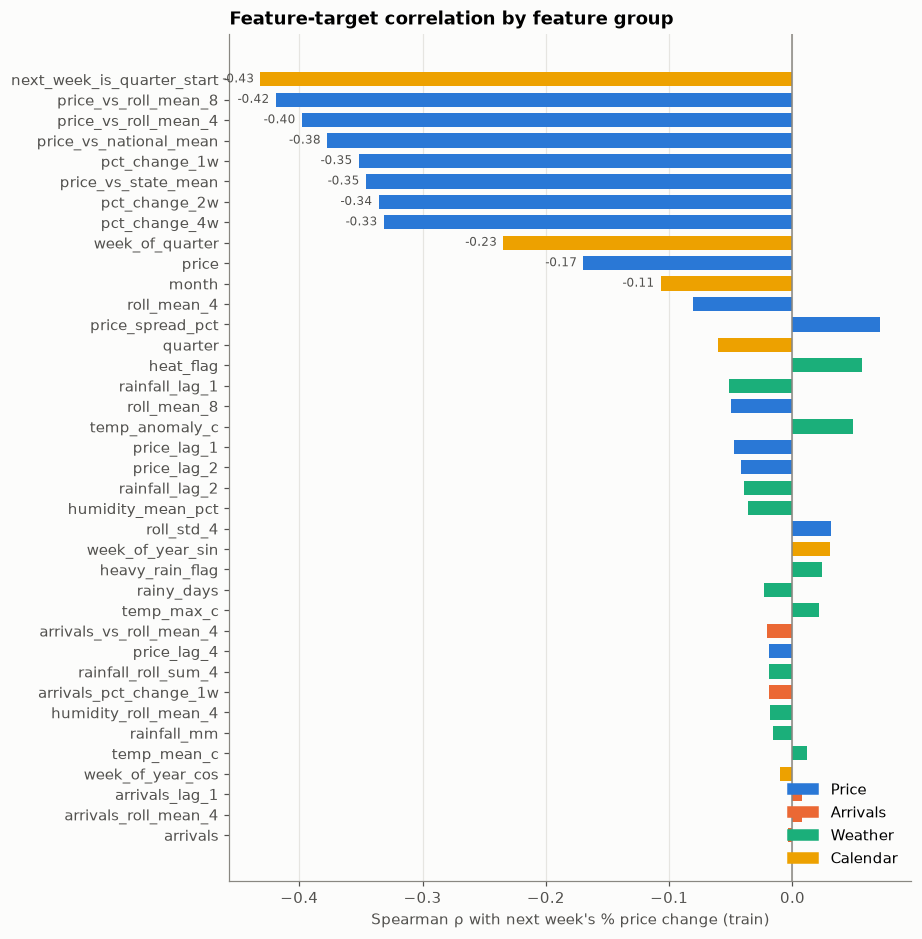

next_week_is_quarter_start   -0.431
price_vs_roll_mean_8         -0.419
price_vs_roll_mean_4         -0.398
price_vs_national_mean       -0.377
pct_change_1w                -0.352
price_vs_state_mean          -0.346
pct_change_2w                -0.336
pct_change_4w                -0.332
week_of_quarter              -0.234
price                        -0.170
dtype: float64

In [5]:
train = feats[feats["split"] == "train"]
rho = train[NUMERIC_FEATURES].corrwith(train["target_pct_change"], method="spearman").sort_values(key=abs)
print("Flagged |rho| > 0.8:", list(rho[rho.abs() > 0.8].index) or "none")

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(rho.index, rho.values, color=[GROUP_COLORS[GROUP[f]] for f in rho.index], height=0.7)
ax.axvline(0, color=MUTED, lw=1)
for f, v in rho.items():
    if abs(v) >= 0.1:
        ax.annotate(f"{v:+.2f}", (v, f), xytext=(4 if v > 0 else -4, 0), textcoords="offset points",
                    ha="left" if v > 0 else "right", va="center", fontsize=8, color=INK2)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in GROUP_COLORS.values()]
ax.legend(handles, GROUP_COLORS.keys(), frameon=False, loc="lower right")
ax.set_xlabel("Spearman ρ with next week's % price change (train)")
ax.set_title("Feature-target correlation by feature group")
ax.grid(axis="y", visible=False)
fig.savefig(FIG / "feature_target_correlation.png"); plt.show()
rho.sort_values(key=abs, ascending=False).head(10).round(3)

## 4. Multicollinearity

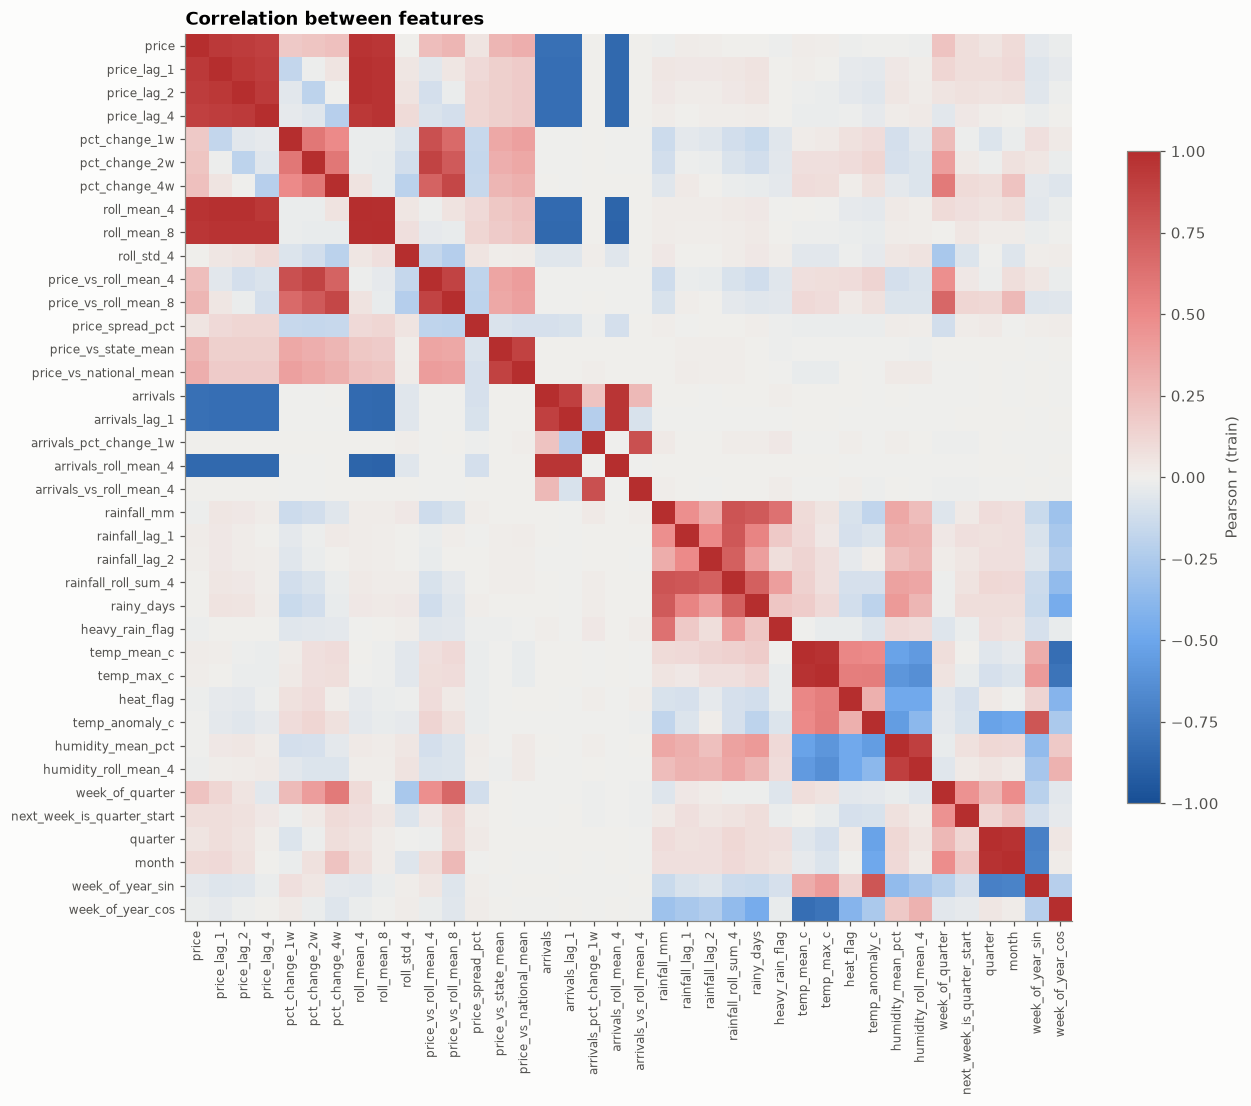

19 feature pairs with |r| > 0.9


,level_0,level_1,r
238,roll_mean_4,roll_mean_8,0.988
77,price_lag_2,roll_mean_4,0.977
42,price_lag_1,roll_mean_4,0.977
637,temp_mean_c,temp_max_c,0.972
697,quarter,month,0.972
112,price_lag_4,roll_mean_8,0.968
6,price,roll_mean_4,0.967
78,price_lag_2,roll_mean_8,0.966
43,price_lag_1,roll_mean_8,0.961
473,arrivals_lag_1,arrivals_roll_mean_4,0.960


In [6]:
corr = train[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="Pearson r (train)")
ax.set_title("Correlation between features")
fig.savefig(FIG / "feature_correlation_matrix.png"); plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack().rename("r").reset_index())
high = pairs[pairs["r"].abs() > 0.9].sort_values("r", key=abs, ascending=False)
print(f"{len(high)} feature pairs with |r| > 0.9")
high.round(3)

In [7]:
X = train[NUMERIC_FEATURES]
Xs = (X - X.mean()) / X.std()
Xs = Xs.assign(const=1.0)
vif = pd.Series([variance_inflation_factor(Xs.values, i) for i in range(len(NUMERIC_FEATURES))],
                index=NUMERIC_FEATURES, name="VIF").sort_values(ascending=False)
vif_table = vif.to_frame().assign(group=lambda d: d.index.map(GROUP),
                                  flag=lambda d: np.where(d["VIF"] > 10, "VIF > 10", ""))
vif_table.round(1).to_csv(ROOT / "reports" / "feature_vif.csv")
print(f"{(vif > 10).sum()} of {len(vif)} features have VIF > 10")
vif_table.round(1)

23 of 38 features have VIF > 10


,VIF,group,flag
roll_mean_4,6692.6,Price,VIF > 10
roll_mean_8,2449.1,Price,VIF > 10
price_lag_2,888.7,Price,VIF > 10
price_lag_1,817.8,Price,VIF > 10
price,730.2,Price,VIF > 10
price_lag_4,472.0,Price,VIF > 10
price_vs_roll_mean_4,444.3,Price,VIF > 10
arrivals_roll_mean_4,385.0,Arrivals,VIF > 10
price_vs_roll_mean_8,248.6,Price,VIF > 10
month,210.7,Calendar,VIF > 10


## 5. Save the feature table

In [8]:
out = feats[KEYS + NUMERIC_FEATURES + TARGETS + ["split"]]  # KEYS include crop and state
out.to_csv(DATA / "features_panel.csv", index=False)
print("Saved data/features_panel.csv:", out.shape)
out.head()

Saved data/features_panel.csv: (9030, 46)


,crop,state,district,market_name,week_start_date,price,price_lag_1,price_lag_2,price_lag_4,pct_change_1w,...,humidity_roll_mean_4,week_of_quarter,next_week_is_quarter_start,quarter,month,week_of_year_sin,week_of_year_cos,target_pct_change,target_direction,split
0,Onion,Uttar Pradesh,Agra,Agra Apmc Market,2025-11-24,2044.67,2150.50,2076.50,1946.17,-4.921181,...,68.5000,9,0,4,11,-4.647232e-01,0.885456,4.254965,rise,train
1,Onion,Uttar Pradesh,Agra,Agra Apmc Market,2025-12-01,2131.67,2044.67,2150.50,1985.33,4.254965,...,70.6775,10,0,4,12,-3.546049e-01,0.935016,-8.530401,fall,train
2,Onion,Uttar Pradesh,Agra,Agra Apmc Market,2025-12-08,1949.83,2131.67,2044.67,2076.50,-8.530401,...,73.3200,11,0,4,12,-2.393157e-01,0.970942,9.240293,rise,train
3,Onion,Uttar Pradesh,Agra,Agra Apmc Market,2025-12-15,2130.00,1949.83,2131.67,2150.50,9.240293,...,76.2125,12,0,4,12,-1.205367e-01,0.992709,2.355399,flat,train
4,Onion,Uttar Pradesh,Agra,Agra Apmc Market,2025-12-22,2180.17,2130.00,1949.83,2044.67,2.355399,...,78.3550,13,1,4,12,6.432491e-16,1.000000,-16.374870,fall,train


## 6. Summary

**Feature table:** `data/features_panel.csv` has 9,030 rows (210 mandi-crop series × 43 weeks, 2025-11-24 to 2026-09-14) with 38 numeric features (15 price, 5 arrivals, 12 weather, 6 calendar), the `crop`/`state` categoricals, both targets and a `split` column (train 6,720 rows / 32 weeks; test 2,310 rows / 11 weeks).

**Leakage:** the truncation test passes at all three cut-offs, and no feature has |ρ| > 0.8 with the target. The strongest features make economic sense: `next_week_is_quarter_start` (the known quarter-start drop) and the mean-reversion features (`pct_change_1w`, `price_vs_roll_mean_4/8`).

**Multicollinearity:** the price-level features (`price`, its lags and rolling means) are almost perfectly correlated with each other, and several momentum/deviation features overlap. 19 feature pairs have |r| > 0.9 and 23 of 38 features have VIF > 10 (`roll_mean_4` ≈ 6,700), so a linear model should not use them all as raw inputs. Subtask 4.3 (KAN-11) applies PCA to obtain uncorrelated components.